In [ ]:
import gdown
import zipfile
import os
import shutil

In [ ]:
# Google Drive link
file_url = "https://drive.google.com/file/d/1oUX991nPh4330ZzbXzBKKOAswhx75BtV/view?usp=sharing"

# Output filename
output = "dataset.zip"


In [ ]:
# Download directly from Google Drive
gdown.download(file_url, output, quiet = False, fuzzy = True)

Downloading...
From (original): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV
From (redirected): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV&confirm=t&uuid=96509283-dbe6-448e-b473-2c64901b7267
To: /content/dataset.zip
100%|██████████| 9.26G/9.26G [01:30<00:00, 102MB/s] 


'dataset.zip'

Loading images

In [ ]:
import random
import zipfile
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [39]:
print("Total files extracted:", sum(len(files) for _, _, files in os.walk("/content/images")))
print("Sample files:", os.listdir("/content/images")[:10])

Total files extracted: 34731
Sample files: ['images']


In [25]:
image_dir = f"{extract_dir}/images/"

In [29]:
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')]

In [30]:
# List files in the image directory
print(os.listdir(image_dir))

['d5ff83ea97df2f1562770de595a0448926dc624d.jpg', '2532ecfdd327c504d74d3ef33dc0ad18b8a3c0fa.jpg', 'b8bd11e16e00484d21825dc5e77c04fb78966983.jpg', '7a055137811a7901cb0724b136beac4d11c54b75.jpg', 'eaff2aa301382444be27f95b6b11aae4e9532165.jpg', '0345e21c23d51222087197e8cd5441004d3a8923.jpg', 'bdcfb34175d6d54e70b313a8b9b5bce57652b70f.jpg', '9c9732f6a23d8edb4f4a9d0acf4a7aab67c462e5.jpg', '8ac85f2228ef5d39fc52ae1568c35c4c657ce6f5.jpg', '1f8480032ba91fea32db3c3a045b8f6fec0e23a9.jpg', '26f84304b50cb5456a0dfa351afd77f944c61b30.jpg', 'c8e3ccafa69d3f19883a8051a105e73e0d630a47.jpg', '08dc392d15e4072a1f116193d708ee64dc70cfb1.jpg', '7323c4c74ec1df254e123545a6f9560074572fb4.jpg', 'c838d44b26e779ef02ad78f05dac02a7fa6376cf.jpg', '1ec51fd574433d1102c66f8db1092655eab307f2.jpg', '1872b162a0ea409a14851eaa783df08da5787eb2.jpg', 'a28afb1f2709e47d9b7f710fe358261144ed4d01.jpg', '2ed19711074a06df13ed5bd83bb15d6f29a8a0e6.jpg', 'e2930ef98b88363b41de24a97a4ceae0e2df4277.jpg', '73e2aa75c6549742c0465a372ea846c03f4f19

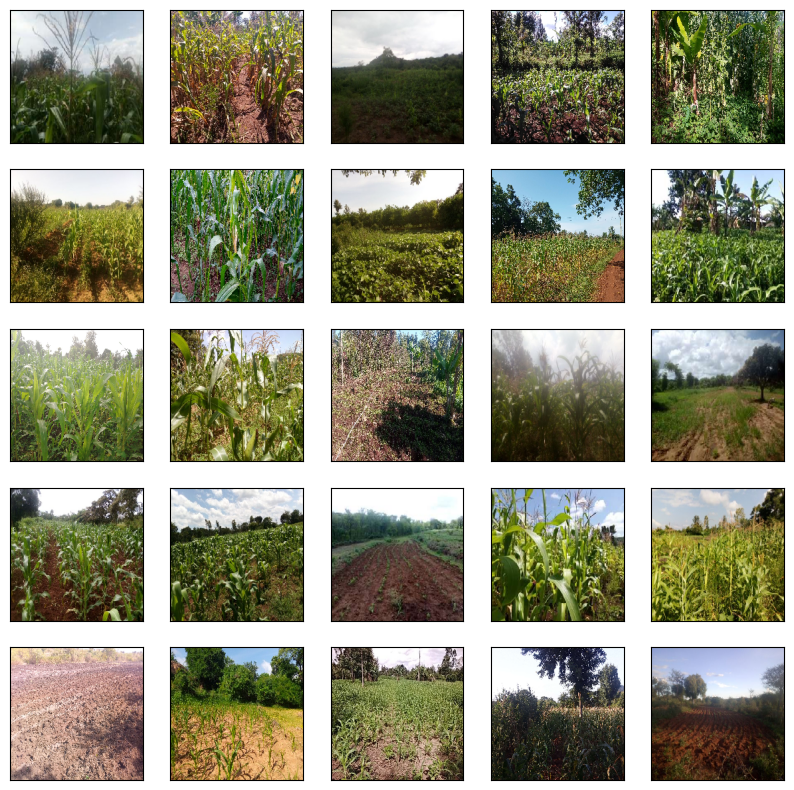

In [35]:
plt.figure(figsize = (10, 10))
# Select a subset of image files to display
sample_files = random.sample(image_files, min(25, len(image_files)))
for i, file in enumerate(sample_files):
  img_path = os.path.join(image_dir, file)
  img = image.load_img(img_path, target_size = (200, 200))  # Adjust the target size as needed
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(img)
plt.show()

In [67]:
from PIL import Image
from tqdm import tqdm
import hashlib
import pandas as pd

In [40]:
input_dir = "/content/images"

In [57]:
# pick first 10 image paths
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


In [49]:
# Target Size
size = (320, 240)

In [59]:
for img_path in tqdm(image_files, desc = "Resizing images"):
    try:
        with Image.open(img_path).convert("RGB") as img:
            img = img.resize(size, Image.Resampling.LANCZOS)
            img.save(img_path, "JPEG")
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(img_path)}: {e}")

Resizing images: 100%|██████████| 34731/34731 [32:15<00:00, 17.94it/s]


In [60]:
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


In [64]:
seen = set()
duplicates = []

for path in tqdm(image_files, desc = "Checking for duplicates"):
    try:
        with open(path, "rb") as f:
            hash_val = hashlib.md5(f.read()).hexdigest()
        if hash_val in seen:
            os.remove(path)
            duplicates.append(path)
        else:
            seen.add(hash_val)
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(path)}: {e}")

print(f"✅ Removed {len(duplicates)} duplicate images")

Checking for duplicates: 100%|██████████| 34731/34731 [00:05<00:00, 6475.00it/s] 

✅ Removed 0 duplicate images


In [66]:
bad_files = []

for path in tqdm(image_files, desc="Checking for corrupted images"):
    try:
        img = Image.open(path)
        img.verify()  # check if corrupted
    except Exception:
        bad_files.append(path)
        os.remove(path)

print(f"✅ Removed {len(bad_files)} corrupted images")

Checking for corrupted images: 100%|██████████| 34731/34731 [00:02<00:00, 13080.07it/s]

✅ Removed 0 corrupted images


In [69]:
train = pd.read_csv("Train.csv")

In [70]:
train.head()

,ID,damage,filename
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg


In [71]:
train_list = list(train["filename"])

In [73]:
train_list[:5]

['d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg',
 '9ea16180c50d0cd539897eefbfe585314e50a56b.jpg',
 'b6b564844041bc68774a553eaf43d61654657dd9.jpg',
 '62262859f0cd411aaf484082ed3ef0b625bc452a.jpg',
 '03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg']

In [74]:
import shutil
from pathlib import Path

In [ ]:
train_dir = image_dir.parent / "train"
train_dir.mkdir(exist_ok = True)

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test = train_test_split(train_list, test_size = 0.2, random_state = 42)

In [78]:
len(X_train)

20854

In [79]:
len(X_test)

5214

In [80]:
len(train_list)

26068

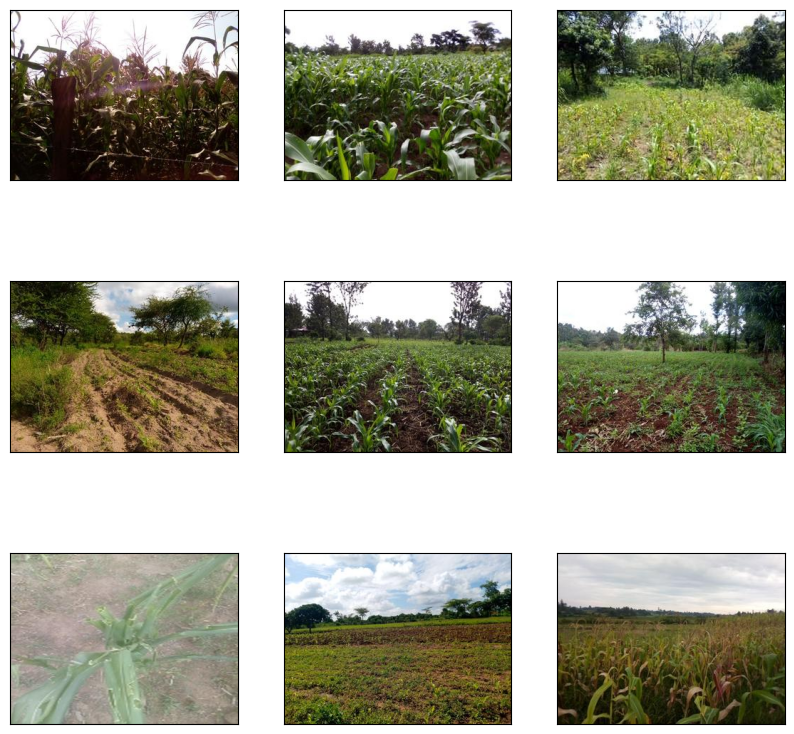

In [82]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Display the first 9 images from the training set
plt.figure(figsize = (10, 10))
for i in range(9):
    img_path = os.path.join(image_dir, X_train[i])
    img = mpimg.imread(img_path)
    plt.subplot(330 + 1 + i)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img)
plt.show()

# always use the path not the list